In [2]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('seaborn-v0_8-darkgrid')

def min_max_normalize(arr):
    arr = np.asarray(arr, dtype=float)
    arr_min = arr.min()
    arr_max = arr.max()
    return (arr - arr_min) / (arr_max - arr_min)

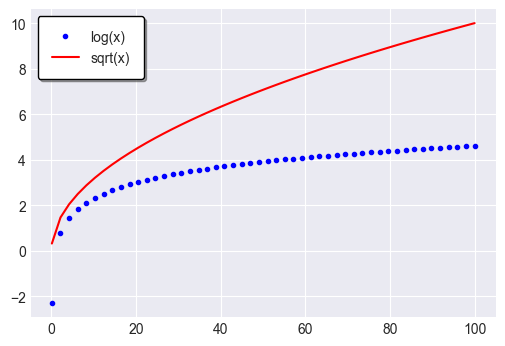

In [4]:
x = np.linspace(0.1, 100, 50)
fig, ax = plt.subplots()
fig.set_size_inches(6, 4)
ax.plot(x, np.log(x), '.b', label='log(x)')
ax.plot(x, np.sqrt(x), '-r', label='sqrt(x)')

leg = ax.legend(
    loc='upper left',
    frameon=True,
    shadow=True,
    fancybox=True,
    framealpha=1,
    borderpad=1,
    facecolor='white',
    edgecolor='black'
 )

Text(0, 0.5, 'normalized y')

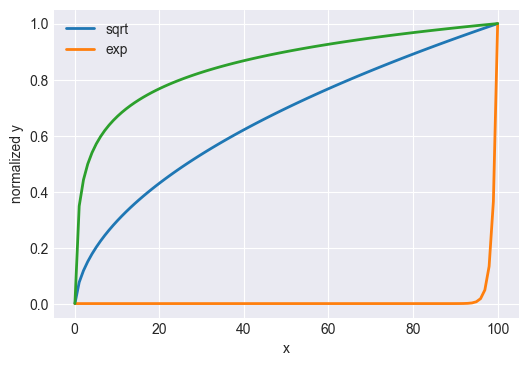

In [5]:
x = np.linspace(0.1, 100, 100)

y = np.column_stack([
    min_max_normalize(np.sqrt(x)),
    min_max_normalize(np.exp(x)),
    min_max_normalize(np.log(x))
])

fig, ax = plt.subplots()
fig.set_size_inches(6, 4)
lines = ax.plot(x, y, linewidth=2)

ax.legend(lines[:2], ['sqrt', 'exp'])
ax.set_xlabel('x')
ax.set_ylabel('normalized y')

# legend for size of points

<class 'pandas.DataFrame'>
Index: 135 entries, 10176 to 52191
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    135 non-null    float64 
 1   cut      135 non-null    category
 2   color    135 non-null    category
 3   clarity  135 non-null    category
 4   depth    135 non-null    float64 
 5   table    135 non-null    float64 
 6   price    135 non-null    int64   
 7   x        135 non-null    float64 
 8   y        135 non-null    float64 
 9   z        135 non-null    float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 9.8 KB


Text(0.5, 1.0, 'Diamond Price vs Carat (marker size scaled by depth)')

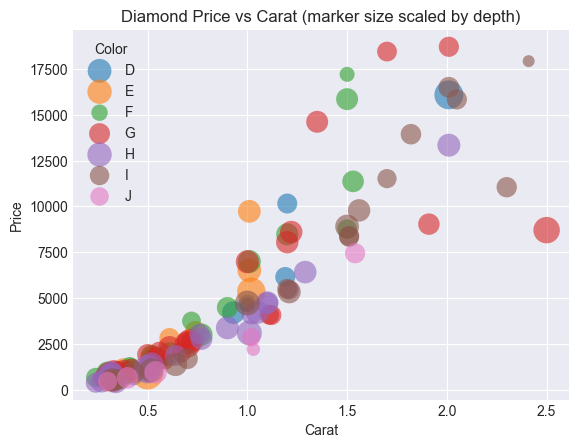

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from seaborn import load_dataset

diamonds = load_dataset('diamonds').sample(frac=0.0025, random_state=0)
diamonds.info()

color_dict = {
    'D': '#1f77b4',
    'E': '#ff7f0e',
    'F': '#2ca02c',
    'G': '#d62728',
    'H': '#9467bd',
    'I': '#8c564b',
    'J': '#e377c2'
}

dmin = diamonds['depth'].min()
dmax = diamonds['depth'].max()
diamonds['size_scaled'] = 500 * (diamonds['depth'] - dmin) / (dmax - dmin)

fig, ax = plt.subplots()
for clr in sorted(diamonds['color'].unique()):
    subset = diamonds[diamonds['color'] == clr]
    ax.scatter(
        subset['carat'],
        subset['price'],
        s=subset['size_scaled'],
        c=color_dict[clr],
        marker='o',
        alpha=0.6,
        edgecolors='none',
        label=clr
    )

ax.legend(title='Color', scatterpoints=1)
ax.set_xlabel('Carat')
ax.set_ylabel('Price')
ax.set_title('Diamond Price vs Carat (marker size scaled by depth)')

# Multiple legends

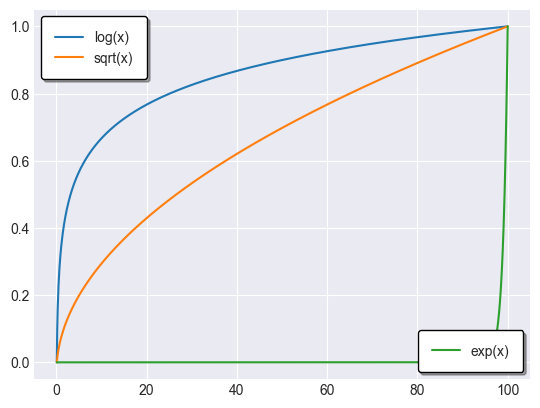

In [ ]:
x = np.linspace(0.1, 100, 1000)
y_1 = min_max_normalize(np.log(x))
y_2 = min_max_normalize(np.sqrt(x))
y_3 = min_max_normalize(np.exp(x))
fig, ax = plt.subplots()
lines = [
    ax.plot(x, y_1, label='log(x)')[0],
    ax.plot(x, y_2, label='sqrt(x)')[0],
    ax.plot(x, y_3, label='exp(x)')[0]
]

legend_top_left = ax.legend(
    lines[:2],
    ['log(x)', 'sqrt(x)'],
    loc='upper left',
    frameon=True,
    shadow=True,
    fancybox=True,
    framealpha=1,
    borderpad=1,
    facecolor='white',
    edgecolor='black'
 )
ax.add_artist(legend_top_left)

ax.legend(
    lines[2:],
    ['exp(x)'],
    loc='lower right',
    frameon=True,
    shadow=True,
    fancybox=True,
    framealpha=1,
    borderpad=1,
    facecolor='white',
    edgecolor='black'
 )